# LACT 强度干涉：可复用完整流程

本教程只有一条数据链：

**源模型 → 32镜 UVW → 带噪声的 $|V|^2$ → 独立重建**。

修改第2节参数即可模拟自己的情况。论文级大规模盲检仍在
`lact_sii_paper_simulation.ipynb`；这里故意只跑一个2小时情景，便于理解和调试。

## 1. 导入统一接口

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "python" / "sii_unified.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "python"))

from sii_unified import (
    BinarySource, Instrument, Observation, generate_uvw,
    load_empirical_charge_factors, load_measured_spe_template,
    load_optical_timing_mixture, reconstruct_uv, run_sii_pipeline,
    simulate_short_pair_waveforms, simulate_uv_observation,
)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Noto Sans SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 只在这里修改自己的参数

`Instrument.from_repository()` 每次运行都读取 main 当前使用的镜面反射率、
滤光片、PDE、NSB光谱、SPE模板、采样间隔和微单元配置。没有实测来源的
200 MHz带宽、ADC量程、电子噪声和标定稳定性仍是可替换假设。

In [2]:
layout_path = REPO_ROOT / "configs/arrays/layout_0803_reco32_coordinates.csv"
instrument = Instrument.from_repository(REPO_ROOT)
source = BinarySource(
    ab_magnitude=3.0, separation_mas=0.20, position_angle_deg=35.0,
    flux_ratio_secondary_to_primary=0.55,
    primary_diameter_mas=0.060, secondary_diameter_mas=0.040)
observation = Observation(
    site_lat_deg=29.36, source_dec_deg=22.0,
    hours_per_night=2.0, nights=1, segment_s=1200.0)
reconstruction_options = dict(
    grid_size=24, fov_mas=0.70, support_radius_mas=0.32,
    starts=2, max_iter=350, smoothness=0.020,
    huber_delta=0.15, peak_minimum_separation_mas=0.10)

display(pd.DataFrame([asdict(source)]).T.rename(columns={0:"source"}))
display(pd.DataFrame([asdict(observation)]).T.rename(columns={0:"observation"}))
display(pd.DataFrame([asdict(instrument)])[['effective_area_m2','throughput',
    'detected_nsb_rate_hz','electronics_bandwidth_hz','adc_sample_rate_hz',
    'microcells_per_pixel','microcell_recovery_time_ns','parameter_source']].T)

,source
ab_magnitude,3.00
separation_mas,0.20
position_angle_deg,35.00
flux_ratio_secondary_to_primary,0.55
primary_diameter_mas,0.06
secondary_diameter_mas,0.04


,observation
site_lat_deg,29.36
source_dec_deg,22.00
hours_per_night,2.00
nights,1.00
segment_s,1200.00


,0
effective_area_m2,24.57686
throughput,0.2
detected_nsb_rate_hz,70527457.074811
electronics_bandwidth_hz,200000000.0
adc_sample_rate_hz,250000000.0
microcells_per_pixel,270336
microcell_recovery_time_ns,10.0
parameter_source,E:\LACT_pylast2\lact_sii_unified\configs\examp...


## 3. 一键运行完整流程

对两镜基线 $\mathbf B_{ij}=\mathbf r_j-\mathbf r_i$：

$$
(u,v,w)=(\mathbf B\cdot\hat u,\mathbf B\cdot\hat v,
         \mathbf B\cdot\hat s),\qquad \tau_g=w/c.
$$

双星给出理论 $|V(u,v)|^2$。每台镜每20分钟独立抽样恒星和NSB的
Poisson总计数；同一台镜的计数、增益和时钟误差被其所有基线共享。

In [3]:
result = run_sii_pipeline(
    layout_path, source, observation, instrument, seed=20260825,
    reconstruction_kwargs=reconstruction_options)
uvw = result.uvw
measurements = result.measurements
reconstruction = result.reconstruction

print(f"telescopes=32, baselines=496, uv rows={len(uvw):,}")
display(pd.DataFrame([result.metadata]).T.rename(columns={0:"value"}))
display(measurements[['telescope_i','telescope_j','hour_angle_h',
    'u_lambda','v_lambda','visibility2_true','visibility2_measured',
    'sigma_visibility2']].head())

telescopes=32, baselines=496, uv rows=2,976


,value
hours_per_night,2.0
nights,1
total_integration_hours,2.0
source_ab_magnitude,3.0
detected_star_rate_MHz,84.976101
source_case,binary
nsb_multiplier,1.0
nsb_rate_MHz,70.527457
electronics_case,reference
electronics_correlation_efficiency,0.989849


,telescope_i,telescope_j,hour_angle_h,u_lambda,v_lambda,visibility2_true,visibility2_measured,sigma_visibility2
0,TEL.1,TEL.2,-0.833333,2.907470e+08,-1.618563e+08,0.971861,0.630341,0.308630
1,TEL.1,TEL.2,-0.500000,2.359782e+08,-2.341827e+08,0.955227,0.802725,0.298584
2,TEL.1,TEL.2,-0.166667,1.041015e+08,-3.155506e+08,0.689894,0.342411,0.291619
3,TEL.1,TEL.2,0.166667,-9.822435e+07,-3.173956e+08,0.374242,-0.053471,0.280038
4,TEL.1,TEL.2,0.500000,-2.315626e+08,-2.384197e+08,0.344366,0.018757,0.292005


## 4. 查看 UV 测量和独立重建

重建器只读取 $(u,v,\widehat{|V|^2},\sigma)$，不读取源真值。因此以后可把
`reconstruct_uv(measurements, ...)` 单独用于其他模拟或真实相关器数据。

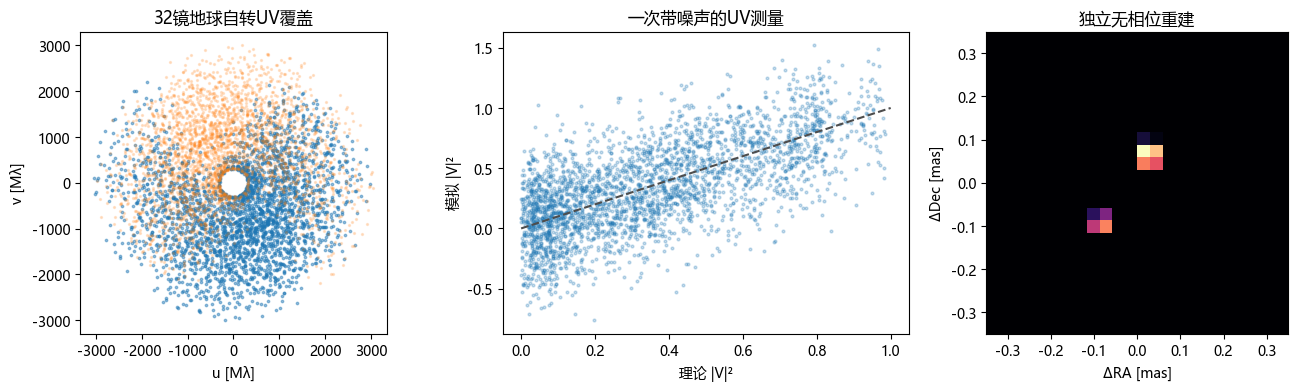

,value
algorithm,positive_softmax_multistart_lbfgsb
objective,0.014415
fit_rmse,0.220825
weighted_fit_rmse,0.17725
fit_mae,0.167407
selected_start,1
starts,2
optimizer_success,True
optimizer_status,0
optimizer_message,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
axes[0].scatter(uvw.u_lambda/1e6, uvw.v_lambda/1e6, s=3, alpha=.45)
axes[0].scatter(-uvw.u_lambda/1e6, -uvw.v_lambda/1e6, s=2, alpha=.18)
axes[0].set(title="32镜地球自转UV覆盖", xlabel="u [Mλ]", ylabel="v [Mλ]")
axes[0].set_aspect('equal', adjustable='box')
axes[1].scatter(measurements.visibility2_true,
                measurements.visibility2_measured, s=4, alpha=.25)
axes[1].plot([0,1],[0,1],'--',color='.3')
axes[1].set(title="一次带噪声的UV测量", xlabel="理论 |V|²", ylabel="模拟 |V|²")
extent = [reconstruction.theta_mas[0], reconstruction.theta_mas[-1]]*2
axes[2].imshow(reconstruction.image, origin='lower', extent=extent, cmap='magma')
axes[2].set(title="独立无相位重建", xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
plt.show()
display(pd.DataFrame([reconstruction.metrics]).T.rename(columns={0:"value"}))

## 5. 2 μs短波形只是电子学闭合检查

单p.e.模板支持约170–180 ns，所以有效记录改为2 μs，并在两侧自动额外生成
至少一个完整模板长度的光电子。这样边缘p.e.的长尾不会被截断。

微秒波形验证光学时延、SPE叠加、恢复、NSB、噪声和ADC；小时级灵敏度仍使用
上面的长曝光充分统计量，不能用2 μs单帧宣称测到天文相关。

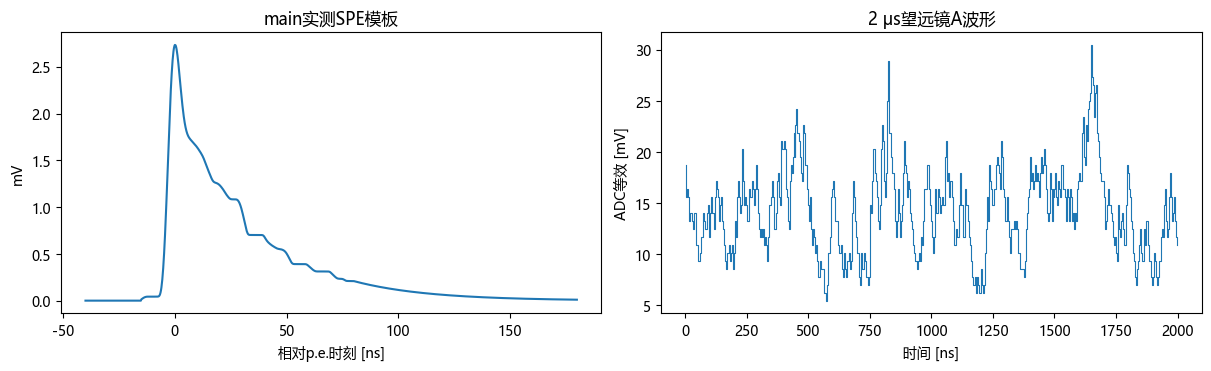

{'analysis_duration_ns': 2000.0, 'samples': 500, 'padding_each_side_ns': 183.20963541394102, 'pe_A_including_padding': 395}


In [5]:
spe_t, spe_v = load_measured_spe_template(instrument.spe_template_path)
charge = load_empirical_charge_factors(instrument.charge_samples_path)
timing = load_optical_timing_mixture(instrument.optical_timing_kernel_path)
waveform = simulate_short_pair_waveforms(
    duration_ns=2000.0,
    star_rate_hz=result.metadata['detected_star_rate_MHz']*1e6,
    nsb_rate_hz=instrument.detected_nsb_rate_hz,
    visibility2=float(np.median(measurements.visibility2_true)),
    instrument=instrument, template_time_ns=spe_t,
    template_amplitude_mv=spe_v, delay_ns=0.2,
    charge_factors=charge, optical_timing_mixture=timing, seed=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
axes[0].plot(spe_t, spe_v)
axes[0].set(title="main实测SPE模板", xlabel="相对p.e.时刻 [ns]", ylabel="mV")
axes[1].step(waveform['sample_time_ns'], waveform['adc_a_mv'], where='mid', lw=.8)
axes[1].set(title="2 μs望远镜A波形", xlabel="时间 [ns]", ylabel="ADC等效 [mV]")
plt.show()
print({
    'analysis_duration_ns': waveform['analysis_duration_ns'],
    'samples': len(waveform['sample_time_ns']),
    'padding_each_side_ns': waveform['simulated_padding_each_side_ns'],
    'pe_A_including_padding': len(waveform['pe_times_a_ns'])})

## 6. 换参数时怎么做

```python
# 只改星等/双星结构：UVW可复用
my_source = replace(source, ab_magnitude=5, separation_mas=0.12)
my_measurements, meta = simulate_uv_observation(
    uvw, my_source, observation, instrument, seed=10)
my_image = reconstruct_uv(my_measurements, **reconstruction_options)

# 改赤纬、观测时段、波长或阵列：重新生成UVW，最省事是再跑一键流程
my_observation = replace(observation, source_dec_deg=40, nights=5)
my_result = run_sii_pipeline(
    layout_path, my_source, my_observation, instrument)

# 改main cfg/曲线后重新读取；单个研究假设可显式覆盖
instrument = Instrument.from_repository(REPO_ROOT)
quieter = replace(instrument, electronic_noise_rms_mv=0.20)
```

## 7. Checks

In [6]:
expected_rows = 496 * round(observation.hours_per_night*3600/observation.segment_s)
checks = {
    '完整UV行数': len(uvw) == expected_rows,
    'UVW有限': np.isfinite(uvw[['u_m','v_m','w_m']]).all().all(),
    '测量有限': np.isfinite(measurements.visibility2_measured).all(),
    '误差为正': (measurements.sigma_visibility2 > 0).all(),
    '重建归一化': np.isclose(reconstruction.image.sum(), 1.0),
    '短波形至少1微秒': waveform['analysis_duration_ns'] >= 1000,
    'SPE边缘有缓冲': waveform['simulated_padding_each_side_ns'] >= max(abs(spe_t)),
}
display(pd.DataFrame({'check': checks.keys(), 'passed': checks.values()}))
assert all(checks.values()), checks
print('ALL CHECKS PASSED')

,check,passed
0,完整UV行数,True
1,UVW有限,True
2,测量有限,True
3,误差为正,True
4,重建归一化,True
5,短波形至少1微秒,True
6,SPE边缘有缓冲,True


ALL CHECKS PASSED
